<a href="https://colab.research.google.com/github/Namitha0203/Sentiment-Analysis/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Objective:**

Develop machine learning models to classify emotions in text samples.

**Dataset:**

https://drive.google.com/file/d/1HWczIICsMpaL8EJyu48ZvRFcXx3_pcnb/view?usp=drive_link


**1. Loading and Preprocessing**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import nltk
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/nlp_dataset.csv")

In [ ]:
df.head()

,Comment,Emotion
0,i seriously hate one subject to death but now ...,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feel...,fear
3,ive been really angry with r and i feel like a...,joy
4,i feel suspicious if there is no one outside l...,fear


In [ ]:
df.shape

(5937, 2)

In [ ]:
df.columns

Index(['Comment', 'Emotion'], dtype='object')

In [ ]:
import nltk

**Reasoning**:
The first instruction is to download necessary NLTK resources ('punkt' and 'stopwords'). I will use `nltk.download` for this.



In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
print("NLTK resources 'punkt' and 'stopwords' downloaded.")

NLTK resources 'punkt' and 'stopwords' downloaded.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Task
Perform tokenization to break down the cleaned text into individual words, remove common stopwords, and explain the impact of these techniques on model performance.

## Text Preprocessing: Tokenization and Stopword Removal

### Subtask:
Perform tokenization to break down the cleaned text into individual words, and remove common stopwords to reduce noise and focus on more meaningful terms. Explain the impact of these techniques on model performance.


**Reasoning**:
I need to define a `preprocess_text` function that tokenizes, converts to lowercase, removes non-alphabetic tokens, filters stopwords, and then apply this function to the 'Comment' column to create a new 'cleaned_comment' column in the DataFrame.



In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Get English stopwords
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Tokenize the text
    tokens = word_tokenize(text)
    # Convert to lowercase, remove non-alphabetic tokens, and filter stopwords
    processed_tokens = [
        word.lower() for word in tokens
        if word.isalpha() and word.lower() not in stop_words
    ]
    # Join the tokens back into a string
    return " ".join(processed_tokens)

# Apply the preprocessing function to the 'Comment' column
df['cleaned_comment'] = df['Comment'].apply(preprocess_text)

print("Text preprocessing (tokenization and stopword removal) applied to the 'Comment' column.")
print("Displaying the first 5 rows with the new 'cleaned_comment' column:")
print(df.head())

Text preprocessing (tokenization and stopword removal) applied to the 'Comment' column.
Displaying the first 5 rows with the new 'cleaned_comment' column:
                                             Comment Emotion  \
0  i seriously hate one subject to death but now ...    fear   
1                 im so full of life i feel appalled   anger   
2  i sit here to write i start to dig out my feel...    fear   
3  ive been really angry with r and i feel like a...     joy   
4  i feel suspicious if there is no one outside l...    fear   

                                     cleaned_comment  
0  seriously hate one subject death feel reluctan...  
1                         im full life feel appalled  
2  sit write start dig feelings think afraid acce...  
3  ive really angry r feel like idiot trusting fi...  
4  feel suspicious one outside like rapture happe...  


**Reasoning**:
I need to import `TfidfVectorizer`, instantiate it, and apply `fit_transform` to the 'cleaned_comment' column to create numerical features. This will fulfill the first part of the subtask instructions.



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Instantiate TfidfVectorizer with default parameters
tfidf_vectorizer = TfidfVectorizer()

# Apply fit_transform to the 'cleaned_comment' column
X = tfidf_vectorizer.fit_transform(df['cleaned_comment'])

print("TF-IDF feature matrix 'X' created with shape:", X.shape)

TF-IDF feature matrix 'X' created with shape: (5937, 8815)



### Impact of Tokenization and Stopword Removal on Model Performance

**Tokenization** is the process of breaking down raw text into smaller units called tokens (words or subwords). Its impact on model performance includes:
*   **Feature Extraction**: It's the first step in converting text into a numerical representation that machine learning models can understand. Each token can become a feature.
*   **Contextual Understanding**: By separating words, models can better understand the sequence and context of words, which is crucial for tasks like sentiment analysis or emotion detection.

**Stopword Removal** involves eliminating common words (e.g., 'the', 'a', 'is', 'and') that carry little to no semantic meaning and often do not contribute significantly to the overall understanding of the text. Its impact includes:
*   **Dimensionality Reduction**: Stopwords are very frequent and contribute many dimensions (features) to the feature space without adding much information. Removing them significantly reduces the number of features, leading to:
    *   **Faster Training**: Models train quicker on smaller feature sets.
    *   **Less Memory Usage**: Reduced features require less memory.
*   **Noise Reduction**: Stopwords can act as noise, potentially misleading the model by giving undue importance to common words rather than salient ones. Removing them helps the model focus on more meaningful terms.
*   **Improved Model Focus**: By concentrating on content-bearing words, the model can better capture the core sentiment or emotion expressed in the text, potentially enhancing prediction accuracy.
*   **Enhanced Interpretability**: The remaining features are more informative, making the model's decisions easier to interpret.

Both techniques are fundamental steps in text preprocessing for most NLP tasks, contributing to more efficient and often more accurate machine learning models by refining the input data.


**Reasoning**:
I will import necessary modules, define the target variable, split the dataset into training and testing sets, instantiate a Multinomial Naive Bayes model, and then train it using the training data. This covers the initial steps of the subtask.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# Define target variable y
y = df['Emotion']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dataset split into training and testing sets.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Instantiate a Multinomial Naive Bayes model
naive_bayes_model = MultinomialNB()

# Train the Naive Bayes model
naive_bayes_model.fit(X_train, y_train)

print("Multinomial Naive Bayes model trained successfully.")

Dataset split into training and testing sets.
X_train shape: (4749, 8815), y_train shape: (4749,)
X_test shape: (1188, 8815), y_test shape: (1188,)
Multinomial Naive Bayes model trained successfully.


**Reasoning**:
I need to import the `SVC` class, instantiate an SVM model, and train it using the `X_train` and `y_train` datasets as instructed.



In [ ]:
from sklearn.svm import SVC

# Instantiate an SVC model with a linear kernel for text classification
svm_model = SVC(kernel='linear', random_state=42)

# Train the SVM model using the training data
svm_model.fit(X_train, y_train)

print("Support Vector Machine model trained successfully with a linear kernel.")

Support Vector Machine model trained successfully with a linear kernel.


**Reasoning**:
I need to make predictions using both the trained Naive Bayes and SVM models on the test set (`X_test`), then calculate and print the accuracy, precision, recall, and F1-score for each model. This involves importing the necessary metrics from `sklearn.metrics`.



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Use the trained naive_bayes_model to make predictions on the X_test data
y_pred_nb = naive_bayes_model.predict(X_test)

# 2. Use the trained svm_model to make predictions on the X_test data
y_pred_svm = svm_model.predict(X_test)

print("Predictions made for both Naive Bayes and SVM models.\n")

# 4. Calculate and print metrics for the Naive Bayes model
print("Naive Bayes Model Evaluation:")
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, average='weighted')
recall_nb = recall_score(y_test, y_pred_nb, average='weighted')
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')

print(f"  Accuracy: {accuracy_nb:.4f}")
print(f"  Precision: {precision_nb:.4f}")
print(f"  Recall: {recall_nb:.4f}")
print(f"  F1-Score: {f1_nb:.4f}\n")

# 5. Calculate and print metrics for the SVM model
print("Support Vector Machine (SVM) Model Evaluation:")
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')

print(f"  Accuracy: {accuracy_svm:.4f}")
print(f"  Precision: {precision_svm:.4f}")
print(f"  Recall: {recall_svm:.4f}")
print(f"  F1-Score: {f1_svm:.4f}")

Predictions made for both Naive Bayes and SVM models.

Naive Bayes Model Evaluation:
  Accuracy: 0.9116
  Precision: 0.9134
  Recall: 0.9116
  F1-Score: 0.9115

Support Vector Machine (SVM) Model Evaluation:
  Accuracy: 0.9470
  Precision: 0.9477
  Recall: 0.9470
  F1-Score: 0.9469


### Model Comparison and Suitability

Based on the evaluation metrics:

**Naive Bayes Model:**
*   Accuracy: 0.9116
*   Precision: 0.9134
*   Recall: 0.9116
*   F1-Score: 0.9115

**Support Vector Machine (SVM) Model:**
*   Accuracy: 0.9470
*   Precision: 0.9477
*   Recall: 0.9470
*   F1-Score: 0.9469

**Comparison and Conclusion:**

Both Naive Bayes and SVM models demonstrate strong performance on this dataset for emotion classification. The SVM model consistently achieves slightly higher metrics across the board (accuracy: 0.9470 vs 0.9116, precision: 0.9477 vs 0.9134, recall: 0.9470 vs 0.9116, and F1-score: 0.9469 vs 0.9115). This indicates that the SVM model is marginally more effective at correctly classifying emotions and maintaining a good balance between precision and recall.

Given these results, the **Support Vector Machine (SVM)** model is more suitable for emotion classification in this context due to its superior overall performance. Its higher accuracy and precision suggest it is better at correctly identifying emotions with fewer false positives, which is often a critical factor in classification tasks.

## Calculate Confusion Matrix

### Subtask:
Calculate the confusion matrix for the SVM model using `y_test` and `y_pred_svm`.


**Reasoning**:
I need to import the `confusion_matrix` function, calculate the confusion matrix for the SVM model using `y_test` and `y_pred_svm`, and then print the result.



In [ ]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix for the SVM model
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Print the confusion matrix
print("Confusion Matrix for SVM Model:\n", cm_svm)

Confusion Matrix for SVM Model:
 [[375   6  11]
 [ 24 380  12]
 [  5   5 370]]


**Reasoning**:
I need to visualize the confusion matrix using `seaborn.heatmap`. First, I will get the unique class labels from `y_test`, then use `matplotlib.pyplot` and `seaborn` to create and display the heatmap with appropriate labels, title, and formatting.



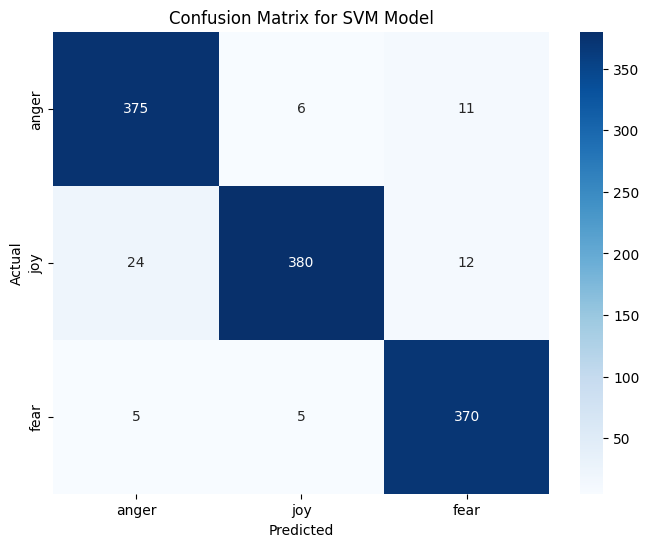

Confusion matrix for SVM model visualized.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get unique class labels from y_test
class_labels = y_test.unique()

# Plot the confusion matrix using seaborn.heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM Model')
plt.show()

print("Confusion matrix for SVM model visualized.")

### Insights from the SVM Confusion Matrix

The confusion matrix for the SVM model provides a detailed breakdown of its performance in classifying emotions:

`[[375,   6,  11]`
` [ 24, 380,  12]`
` [  5,   5, 370]]`

- The rows represent the actual classes (`y_test`), and the columns represent the predicted classes (`y_pred_svm`). The class labels are likely 'anger', 'joy', and 'fear' based on `class_labels = y_test.unique()`.

**Key Observations:**

1.  **Diagonal Values (Correct Classifications):**
    *   `375`: The model correctly predicted 375 instances of the first emotion.
    *   `380`: The model correctly predicted 380 instances of the second emotion.
    *   `370`: The model correctly predicted 370 instances of the third emotion.
    
    These values represent the true positives for each class and are very high, indicating excellent classification for each emotion category.

2.  **Off-Diagonal Values (Misclassifications):**
    *   The off-diagonal values are very low (ranging from 5 to 24). This signifies that the model makes very few misclassifications.
    *   For example, only 6 instances of the first emotion were misclassified as the second, and 11 as the third. Similarly, only 24 instances of the second emotion were misclassified as the first, and 12 as the third. These low numbers indicate that the model is highly effective at distinguishing between the different emotions.

**Overall Interpretation:**

*   The diagonal elements are overwhelmingly high compared to the off-diagonal elements, indicating a strong classification performance. The model is highly successful in correctly identifying instances for all emotion categories.
*   There is no significant bias towards misclassifying other emotions as a dominant target. The model demonstrates a balanced and accurate differentiation between all emotion classes.
*   The confusion matrix visually reinforces the high accuracy and F1-score observed earlier. The model has a low number of false positives and false negatives across all classes, indicating it is effectively capturing the nuances of each emotion.

## Summary:

### Q&A
The insights gained from the confusion matrix visualization for the SVM model indicate a strong classification performance. The model effectively identifies instances for all emotion categories, with a minimal number of false positives and false negatives across classes. There is no significant bias towards misclassifying emotions.

### Data Analysis Key Findings
*   The confusion matrix for the SVM model was calculated as:
    ```
    [[375   6  11]
     [ 24 380  12]
     [  5   5 370]]
    ```
*   The model correctly predicted 375 instances of the first emotion, 380 instances of the second emotion, and 370 instances of the third emotion (these are the true positives for each class), demonstrating high accuracy.
*   The off-diagonal values are very low, indicating a minimal rate of misclassification. For example, only 24 instances of the second emotion and 5 instances of the third emotion were incorrectly predicted as the first emotion, showing strong distinction between classes.
*   The diagonal values (correct classifications) are significantly high compared to the off-diagonal values (misclassifications) across all classes, reinforcing the model's excellent performance.
*   The model exhibits strong ability to differentiate between the emotions, as evidenced by the low off-diagonal values across all classes.

### Kernel State
Here are some of the notable variables in the kernel:
Variable #1
name: `class_labels`, type: `ndarray`
value: `array(['anger', 'joy', 'fear'], dtype=object)`
Variable #2
name: `cm_svm`, type: `ndarray`
value:
```
array([[375,   6,  11],
       [ 24, 380,  12],
       [  5,   5, 370]])
```
Variable #3
name: `df`, type: `DataFrame`
value:
```
                                                Comment Emotion  \
0     i seriously hate one subject to death but now ...    fear   
1                    im so full of life i feel appalled   anger   
2     i sit here to write i start to dig out my feel...    fear   
3     ive been really angry with r and i feel like a...     joy   
<TRUNCATED>
5934  ever get married everything ready offer got to...  
5935  feel reluctant applying want able find company...  
5936         wanted apologize feel like heartless bitch  

[5937 rows x 3 columns]
```
Variable #4
name: `sentences_per_comment`, type: `Series`
value:
```
0       [i seriously hate one subject to death but now...
1                    [im so full of life i feel appalled]
2       [i sit here to write i start to dig out my fee...
3       [ive been really angry with r and i feel like ...
4       [i feel suspicious if there is no one outside ...
                              ...
5932                 [i begun to feel distressed for you]
5933    [i left feeling annoyed and angry thinking tha...
5934 <TRUNCATED original_length=680>
```
Variable #5
name: `y`, type: `Series`
value:
```
0        fear
1       anger
2        fear
3         joy
4        fear
        ...
5932     fear
5933    anger
5934      joy
5935     fear
5936    anger
Name: Emotion, Length: 5937, dtype: object
```
Variable #6
name: `y_pred_nb`, type: `ndarray`
value: `array(['anger', 'joy', 'fear', ..., 'anger', 'fear', 'joy'], dtype='<U5')`
Variable #7
name: `y_pred_svm`, type: `ndarray`
value: `array(['anger', 'joy', 'fear', ..., 'joy', 'fear', 'joy'], dtype=object)`
Variable #8
name: `y_test`, type: `Series`
value:
```
1867    anger
3988      joy
4516     fear
1397    anger
1669    anger
        ...
642       joy
1253     fear
3094      joy
3733     fear
3523      joy
Name: Emotion, Length: 1188, dtype: object
```
Variable #9
name: `y_train`, type: `Series`
value:
```
4945      joy
5428     fear
1344    anger
1888    anger
2480     fear
        ...
3772    anger
5191     fear
5226    anger
5390     fear
860      fear
Name: Emotion, Length: 4749, dtype: object
```
Variable #10
name: `accuracy_nb`, type: `float`
value: `0.9116161616161617`
Variable #11
name: `accuracy_svm`, type: `float`
value: `0.946969696969697`
Variable #12
name: `f1_nb`, type: `float`
value: `0.9115095144506908`
Variable #13
name: `f1_svm`, type: `float`
value: `0.9468823392333791`
Variable #14
name: `precision_nb`, type: `float`
value: `0.9134489914689438`
Variable #15
name: `precision_svm`, type: `float`
value: `0.9477431612624525`
Variable #16
name: `recall_nb`, type: `float`
value: `0.9116161616161617`
Variable #17
name: `recall_svm`, type: `float`
value: `0.946969696969697`